In [ ]:
!pip install textblob

In [ ]:
import torch


print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device:        {torch.cuda.get_device_name(0)}")
    print(f"bf16 support:  {torch.cuda.is_bf16_supported()}")

cuda available: True
device:        Tesla T4
bf16 support:  True


In [ ]:
import pandas as pd


DATA_URL = "https://raw.githubusercontent.com/nickkats1/Bert-T5-GPT2/main/data/guardian_headlines.csv"

frame = pd.read_csv(DATA_URL, usecols=["Headlines"]).dropna().drop_duplicates(ignore_index=True)
frame['Headlines'].fillna("", inplace=True)
print(f"{len(frame):,} headlines after cleaning")
frame.head()

17,795 headlines after cleaning


/tmp/ipykernel_11509/1663679511.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  frame['Headlines'].fillna("", inplace=True)


,Headlines
0,Johnson is asking Santa for a Christmas recovery
1,‘I now fear the worst’: four grim tales of wor...
2,Five key areas Sunak must tackle to serve up e...
3,Covid-19 leaves firms ‘fatally ill-prepared’ f...
4,The Week in Patriarchy \n\n\n Bacardi's 'lad...


In [ ]:
from textblob import TextBlob


LABEL_MAP = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {index: name for name, index in LABEL_MAP.items()}


def polarity(text: str) -> float:
    """Return the TextBlob polarity of ``text`` in ``[-1.0, 1.0]``, treating bad input as neutral."""
    if not isinstance(text, str) or not text:
        return 0.0
    return float(TextBlob(text).polarity)


def sentiment(score: float) -> str:
    """Bucket a polarity score into one of ``Negative`` / ``Neutral`` / ``Positive``."""
    if score == 0:
        return "Neutral"
    return "Negative" if score < 0 else "Positive"


frame["labels"] = [LABEL_MAP[sentiment(polarity(text))] for text in frame["Headlines"]]
frame.head()

,Headlines,labels
0,Johnson is asking Santa for a Christmas recovery,1
1,‘I now fear the worst’: four grim tales of wor...,0
2,Five key areas Sunak must tackle to serve up e...,2
3,Covid-19 leaves firms ‘fatally ill-prepared’ f...,1
4,The Week in Patriarchy \n\n\n Bacardi's 'lad...,0


labels
Neutral     9867
Positive    4770
Negative    3158
Name: count, dtype: int64


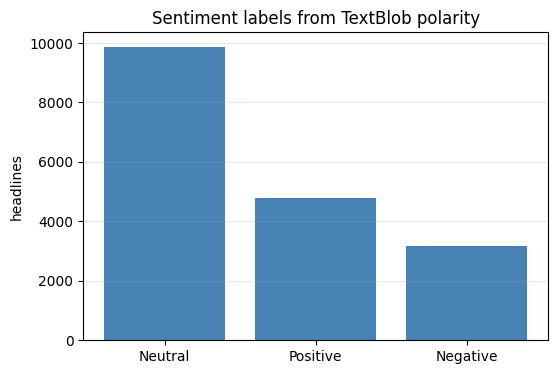

In [ ]:
import matplotlib.pyplot as plt


counts = frame["labels"].map(ID2LABEL).value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color="steelblue")
ax.set_title("Sentiment labels from TextBlob polarity")
ax.set_ylabel("headlines")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer


MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 80
SEED = 42

train, holdout = train_test_split(frame, test_size=0.2, random_state=SEED, stratify=frame["labels"])
validation, test = train_test_split(holdout, test_size=0.5, random_state=SEED, stratify=holdout["labels"])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch: dict) -> dict:
    return tokenizer(batch["Headlines"], truncation=True, max_length=MAX_LENGTH)


datasets = DatasetDict(
    {
        "train": Dataset.from_pandas(train, preserve_index=False),
        "validation": Dataset.from_pandas(validation, preserve_index=False),
        "test": Dataset.from_pandas(test, preserve_index=False),
    }
).map(tokenize, batched=True, remove_columns=["Headlines"])

for name, split in datasets.items():
    print(f"{name:<11} {len(split):>7,} rows  columns={split.column_names}")

example = datasets["train"][0]
print()
print(tokenizer.decode(example["input_ids"]))
print(f"label: {ID2LABEL[example['labels']]}")

Map:   0%|          | 0/14236 [00:00<?, ? examples/s]

Map:   0%|          | 0/1779 [00:00<?, ? examples/s]

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


train        14,236 rows  columns=['labels', 'input_ids', 'attention_mask']
validation    1,779 rows  columns=['labels', 'input_ids', 'attention_mask']
test          1,780 rows  columns=['labels', 'input_ids', 'attention_mask']

[CLS]Commercial landlords expect shortfall on rent day for UK retailers[SEP]
label: Neutral


In [ ]:
from transformers import AutoModelForSequenceClassification


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_MAP),
    id2label=ID2LABEL,
    label2id=LABEL_MAP,
)

print(f"classification head: {model.config.num_labels} logits")

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


classification head: 3 logits


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def score_predictions(y_true, y_pred) -> dict[str, float]:
    """Accuracy plus weighted and macro precision/recall/F1, so class imbalance stays visible."""
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }


def compute_metrics(eval_pred) -> dict[str, float]:
    """``Trainer``-compatible entry point: argmax the logits, then score them."""
    logits, labels = eval_pred
    return score_predictions(labels, np.argmax(logits, axis=-1))

In [ ]:
from transformers import DataCollatorWithPadding, EarlyStoppingCallback, Trainer, TrainingArguments


use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir="/content/modernbert-headlines",
    num_train_epochs=4,
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to="none",
    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets["train"],
    eval_dataset=datasets["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"training on {len(trainer.train_dataset):,} rows, precision={'bf16' if use_bf16 else 'fp16'}")

training on 14,236 rows, precision=bf16


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.364046,0.313995,0.899944,0.907524,0.845419,0.870021
2,0.160662,0.179491,0.945475,0.934604,0.923033,0.928607
3,0.056273,0.213029,0.949972,0.937375,0.932208,0.934745
4,0.006595,0.322778,0.948848,0.938915,0.929025,0.933791


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1780, training_loss=0.2344079761860076, metrics={'train_runtime': 689.1654, 'train_samples_per_second': 82.627, 'train_steps_per_second': 2.583, 'total_flos': 1030379004479376.0, 'train_loss': 0.2344079761860076, 'epoch': 4.0})

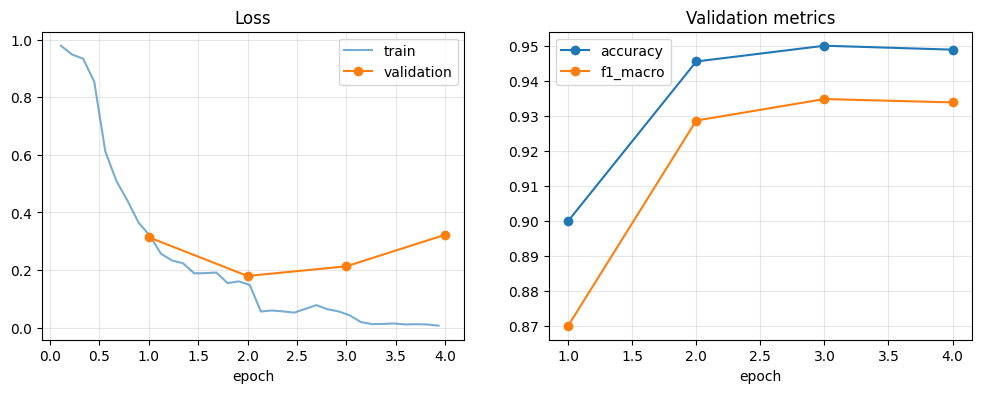

In [ ]:
history = pd.DataFrame(trainer.state.log_history)
steps = history.dropna(subset=["loss"])
evals = history.dropna(subset=["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps["epoch"], steps["loss"], label="train", alpha=0.6)
axes[0].plot(evals["epoch"], evals["eval_loss"], marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(evals["epoch"], evals["eval_accuracy"], marker="o", label="accuracy")
axes[1].plot(evals["epoch"], evals["eval_f1_macro"], marker="o", label="f1_macro")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("epoch")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
prediction = trainer.predict(datasets["test"])
y_pred = np.argmax(prediction.predictions, axis=-1)

for name, value in score_predictions(prediction.label_ids, y_pred).items():
    print(f"{name:<20} {value:.4f}")

accuracy             0.9539
precision_macro      0.9446
recall_macro         0.9378
f1_macro             0.9411


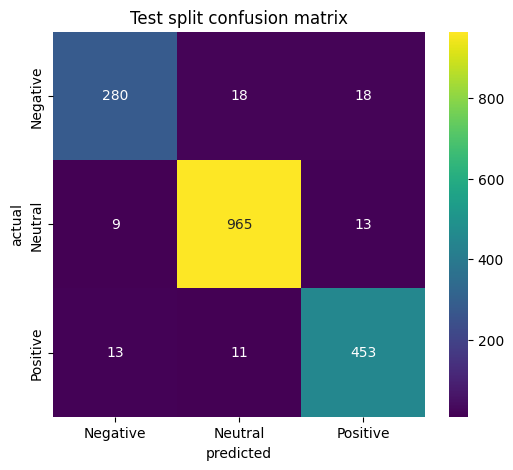

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


class_names = [ID2LABEL[index] for index in sorted(ID2LABEL)]
matrix = confusion_matrix(prediction.label_ids, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="viridis", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Test split confusion matrix")
plt.show()

In [ ]:
from transformers import pipeline


classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

samples = [
    "Record profits lift the FTSE to a new high",
    "Ministers face fresh criticism over delayed inquiry",
    "The committee will publish its findings on Tuesday",
]
for text, result in zip(samples, classifier(samples)):
    print(f"{result['label']:<9} {result['score']:.4f}  {text}")

Positive  0.9999  Record profits lift the FTSE to a new high
Positive  1.0000  Ministers face fresh criticism over delayed inquiry
Neutral   0.9979  The committee will publish its findings on Tuesday


In [ ]:
trainer.save_model("/content/modernbert-headlines")
tokenizer.save_pretrained("/content/modernbert-headlines")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/modernbert-headlines/tokenizer_config.json',
 '/content/modernbert-headlines/tokenizer.json')